# 10 · Consolidación del grupo **LABORATORY**

**Proyecto:** Modelo de longevidad NHANES 2017-2018 (ciclo `_J`)
**Capa:** `01_raw` (.xpt) → **`02_intermediate`** (este notebook) → `03_primary` (merge por `SEQN`)

## Objetivo
Unir los **10 datasets de laboratorio** en un único dataset intermedio, quedándonos
solo con las **columnas relevantes** para el objetivo y construyendo las **features
derivadas** que se pueden calcular sin salir del grupo (las que necesitan edad/sexo
de `DEMO` se difieren al merge).

## Decisión de diseño crítica — target = edad biológica (PhenoAge)
El target del proyecto es la **aceleración de envejecimiento** (PhenoAge de Levine −
edad cronológica). El PhenoAge se construye a partir de **9 biomarcadores de laboratorio**.

> ⚠️ **Circularidad:** esos 9 biomarcadores se usan para *construir el target*, por lo que
> **NO pueden ser también features predictoras**. En este notebook los separamos en un
> bloque aparte (`reservado_target`) y seleccionamos como features solo el **resto** de labs.

**Datasets de este grupo (10):** `biopro_j`, `cbc_j`, `hscrp_j`, `ghb_j`, `hdl_j`,
`tchol_j`, `alb_cr_j`, `cot_j`, `vid_j`, `pbcd_j`.


## 1. Setup

In [1]:
# Cargamos la extension de Kedro para usar el `catalog` igual que en los notebooks 01-06
%load_ext kedro.ipython

[06/16/26 12:49:15] INFO     Using                                                                  ]8;id=14453838;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=14453839;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py#281\281]8;;\
                             'C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages                
                             \kedro\framework\project\rich_logging.yml' as logging configuration.                  

[06/16/26 12:49:16] INFO     Registered line magic '%reload_kedro'                                   ]8;id=14453846;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14453847;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14453853;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14453854;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=14453860;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14453861;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#193\193]8;;\
                             C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes.                                        
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 12:49:26] INFO     No typed parameter requirements found, returning original   ]8;id=14453868;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=14453869;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[06/16/26 12:49:39] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14453876;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=14453877;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/16/26 12:49:41] INFO     Kedro project Nhanes                                                   ]8;id=14453883;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14453884;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14453890;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14453891;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#160\160]8;;\
                             'pipelines'                                                                           

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

# Raiz del proyecto y carpeta de salida (capa 02_intermediate)
PROJ = Path(context.project_path)
OUT_DIR = PROJ / "data" / "02_intermediate"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Proyecto:", PROJ)
print("Salida  :", OUT_DIR)

Proyecto: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes
Salida  : C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate


## 2. Carga de los 10 datasets de laboratorio

Cada archivo de laboratorio tiene un **N distinto** porque algunos provienen de
**submuestras** (p. ej. la bioquímica `BIOPRO` y la HbA1c `GHB` se midieron en la
submuestra de ayuno matinal, ~6.400 personas, mientras que el hemograma `CBC` cubre
~8.400). Ese patrón de "no medido" es **informativo** y lo conservaremos como missing
tras el merge (no es ruido: refleja el diseño muestral).

In [3]:
LAB_DATASETS = [
    "biopro_j_dataset", "cbc_j_dataset", "hscrp_j_dataset", "ghb_j_dataset",
    "hdl_j_dataset", "tchol_j_dataset", "alb_cr_j_dataset", "cot_j_dataset",
    "vid_j_dataset", "pbcd_j_dataset",
]

# Cargamos cada .xpt vía el catálogo de Kedro y guardamos en un dict
raw = {}
for name in LAB_DATASETS:
    df = catalog.load(name)
    short = name.replace("_dataset", "")
    raw[short] = df
    print(f"{short:12s}  filas={df.shape[0]:6d}  columnas={df.shape[1]:3d}")

[06/16/26 12:49:46] INFO     Loading data from biopro_j_dataset (GenericDataset)...            ]8;id=14453898;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14453899;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

biopro_j      filas=  6401  columnas= 41


[06/16/26 12:49:47] INFO     Loading data from cbc_j_dataset (GenericDataset)...               ]8;id=14453904;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14453905;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

cbc_j         filas=  8366  columnas= 22


                    INFO     Loading data from hscrp_j_dataset (GenericDataset)...             ]8;id=14453910;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14453911;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

...

cot_j         filas=  7936  columnas=  5


                    INFO     Loading data from vid_j_dataset (GenericDataset)...               ]8;id=14453946;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14453947;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

vid_j         filas=  8366  columnas=  9


                    INFO     Loading data from pbcd_j_dataset (GenericDataset)...              ]8;id=14453952;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14453953;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

pbcd_j        filas=  8366  columnas= 16


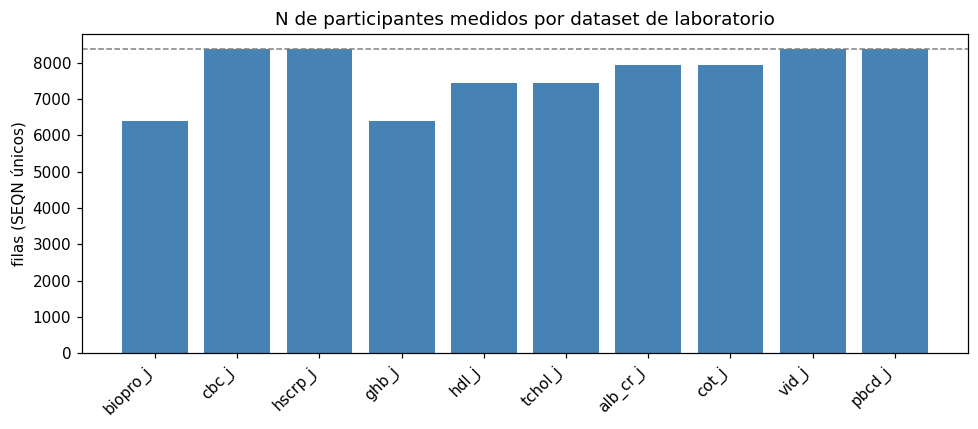

In [4]:
# Grafico 1: N de filas por archivo (evidencia del diseno de submuestras)
ns = {k: v.shape[0] for k, v in raw.items()}
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ns.keys(), ns.values(), color="steelblue")
ax.set_title("N de participantes medidos por dataset de laboratorio")
ax.set_ylabel("filas (SEQN únicos)")
ax.axhline(max(ns.values()), ls="--", c="grey", lw=1)
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 3. Convención de nombres NHANES y limpieza estructural (Filtro 1)

Los laboratorios NHANES repiten cada analito en varias columnas:

| Sufijo | Significado | Acción |
|---|---|---|
| `LBX...` | Medición en **unidades convencionales** | **Conservar** |
| `LBD...SI` | La misma medición en **unidades SI** | **Eliminar** (duplicado exacto) |
| `LBD...LC` / `URD...LC` | *Flag* "por debajo del límite de detección" | **Eliminar** (ruido técnico; NHANES ya imputa el valor por LOD/√2) |
| `URX...` | Medición en orina (unidades convencionales) | Conservar la relevante |

Eliminamos primero los duplicados `SI` y los flags `LC` en todos los datasets.

In [5]:
def drop_si_lc(df):
    """Elimina duplicados en unidades SI (LBD...SI) y flags de LOD (...LC).

    OJO: la regla NO es "termina en SI". Varios analitos primarios terminan en SI
    (GGT=LBXSGTSI, LDH=LBXSLDSI, MCV=LBXMCVSI, WBC=LBXWBCSI, ALP=LBXSAPSI). El
    duplicado en unidades SI siempre EMPIEZA con 'LBD' y termina en 'SI'."""
    cols = [c for c in df.columns
            if not (c.startswith("LBD") and c.endswith("SI"))
            and not c.endswith("LC")]
    return df[cols]

clean = {k: drop_si_lc(v) for k, v in raw.items()}
for k, v in clean.items():
    print(f"{k:12s}  {raw[k].shape[1]:3d} -> {v.shape[1]:3d} columnas")

biopro_j       41 ->  25 columnas
cbc_j          22 ->  22 columnas
hscrp_j         3 ->   2 columnas
ghb_j           2 ->   2 columnas
hdl_j           3 ->   2 columnas
tchol_j         3 ->   2 columnas
alb_cr_j        8 ->   6 columnas
cot_j           5 ->   3 columnas
vid_j           9 ->   5 columnas
pbcd_j         16 ->   6 columnas


## 4. Selección de columnas relevantes

Definimos explícitamente qué columnas conservar y para qué sirven. Las separamos en
**dos bloques**:

### 4.1 Biomarcadores del PhenoAge → `reservado_target` (NO son features)
Los 9 componentes de la fórmula de Levine (2018). Se conservan limpios para construir
el target **después del merge** (PhenoAge necesita además la edad cronológica de `DEMO`).

| Variable | Biomarcador | Dataset |
|---|---|---|
| `LBXSAL`  | Albúmina | BIOPRO |
| `LBXSCR`  | Creatinina sérica | BIOPRO |
| `LBXSGL`  | Glucosa sérica | BIOPRO |
| `LBXSAPSI`| Fosfatasa alcalina (ALP) | BIOPRO |
| `LBXHSCRP`| Proteína C reactiva (hs-CRP) | HSCRP |
| `LBXLYPCT`| Linfocitos % | CBC |
| `LBXMCVSI`| Volumen corpuscular medio (MCV) | CBC |
| `LBXRDW`  | Ancho de distribución eritrocitaria (RDW) | CBC |
| `LBXWBCSI`| Leucocitos (WBC) | CBC |

> Nota: `LBXSAPSI`, `LBXMCVSI`, `LBXWBCSI` traen sufijo `SI` en su nombre *original* pero
> son las únicas columnas de ese analito (no hay duplicado convencional), así que se conservan.

### 4.2 Resto de laboratorios → features candidatas
Solo conservamos lo que aporta señal de envejecimiento/comorbilidad **no contenida** en el PhenoAge.

In [6]:
# --- 4.1 Biomarcadores que CONSTRUYEN el target (no usar como features) ---
PHENOAGE = {
    "LBXSAL":   "Albúmina (g/dL)",
    "LBXSCR":   "Creatinina sérica (mg/dL)",
    "LBXSGL":   "Glucosa sérica (mg/dL)",
    "LBXSAPSI": "Fosfatasa alcalina ALP (U/L)",
    "LBXHSCRP": "hs-CRP (mg/L)",
    "LBXLYPCT": "Linfocitos (%)",
    "LBXMCVSI": "MCV (fL)",
    "LBXRDW":   "RDW (%)",
    "LBXWBCSI": "Leucocitos WBC (1000/uL)",
}

# --- 4.2 Features candidatas (NO PhenoAge), con su justificación ---
LAB_FEATURES = {
    # BIOPRO - función hepática, renal y metabólica (no PhenoAge)
    "LBXSATSI": "ALT - enzima hepática",
    "LBXSASSI": "AST - enzima hepática (para ratio AST/ALT)",
    "LBXSGTSI": "GGT - estrés oxidativo / hepático (sesgada -> log)",
    "LBXSUA":   "Ácido úrico - metabólico / antioxidante",
    "LBXSBU":   "Nitrógeno ureico BUN - función renal (independiente de creatinina)",
    "LBXSTB":   "Bilirrubina total - hepático / antioxidante (forma de U)",
    "LBXSCA":   "Calcio sérico - metabolismo mineral",
    "LBXSTR":   "Triglicéridos séricos - lípidos / metabólico",
    "LBXSGB":   "Globulina - inflamación / inmunidad",
    "LBXSLDSI": "LDH - daño tisular",
    "LBXSIR":   "Hierro sérico - estado de hierro",
    # CBC (no PhenoAge)
    "LBXNEPCT": "Neutrófilos % (para NLR)",
    "LBXMOPCT": "Monocitos % - inflamación crónica",
    "LBXHGB":   "Hemoglobina - anemia (marcador de envejecimiento)",
    "LBXPLTSI": "Plaquetas",
    "LBXMPSI":  "Volumen plaquetario medio (MPV)",
    # Otros labs
    "LBXGH":    "HbA1c - control glucémico (clave)",
    "LBDHDD":   "Colesterol HDL",
    "LBXTC":    "Colesterol total (-> no-HDL, luego se descarta)",
    "URDACT":   "Razón albúmina/creatinina urinaria ACR (sesgada -> log)",
    "LBXCOT":   "Cotinina sérica - tabaquismo objetivo (-> categoría)",
    "LBXVIDMS": "Vitamina D 25-OH total",
    "LBXBPB":   "Plomo en sangre (sesgada -> log)",
    "LBXBCD":   "Cadmio en sangre (sesgada -> log)",
    "LBXTHG":   "Mercurio total en sangre",
    "LBXBSE":   "Selenio en sangre",
    "LBXBMN":   "Manganeso en sangre",
}
print("PhenoAge (target):", len(PHENOAGE), "| Features candidatas:", len(LAB_FEATURES))

PhenoAge (target): 9 | Features candidatas: 27


In [7]:
# Verificamos que cada columna deseada existe en el dataset correcto antes de seleccionar
wanted = set(PHENOAGE) | set(LAB_FEATURES)
found = {}
for short, df in clean.items():
    for c in df.columns:
        if c in wanted:
            found[c] = short
missing = wanted - set(found)
print("Columnas localizadas:", len(found))
print("No encontradas (revisar):", missing if missing else "ninguna ✓")

Columnas localizadas: 36
No encontradas (revisar): ninguna ✓


## 5. Merge interno del grupo (outer join por `SEQN`)

Construimos UNA tabla de laboratorio uniendo los 10 datasets por `SEQN` con **outer join**:
así conservamos a todos los participantes medidos en *cualquier* laboratorio. El missing
resultante refleja el diseño de submuestras (informativo).

In [8]:
# Seleccionamos en cada dataset SEQN + las columnas deseadas que existan ahí
keep_cols = wanted  # PhenoAge + features

frames = []
for short, df in clean.items():
    cols = [c for c in df.columns if c in keep_cols]
    if not cols:
        continue
    sub = df[["SEQN"] + cols].copy()
    sub["SEQN"] = sub["SEQN"].astype("int64")
    sub = sub.drop_duplicates("SEQN").set_index("SEQN")
    frames.append(sub)

lab = frames[0]
for f in frames[1:]:
    lab = lab.join(f, how="outer")  # outer: union de SEQN medidos en cualquier lab

print("Tabla de laboratorio combinada:", lab.shape)
lab.head()

Tabla de laboratorio combinada: (8366, 36)


,LBXSATSI,LBXSAL,LBXSAPSI,LBXSASSI,LBXSBU,LBXSCR,LBXSGB,LBXSGL,LBXSGTSI,LBXSIR,LBXSLDSI,LBXSTB,LBXSCA,LBXSTR,LBXSUA,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXHGB,LBXMCVSI,LBXRDW,LBXPLTSI,LBXMPSI,LBXHSCRP,LBXGH,LBDHDD,LBXTC,URDACT,LBXCOT,LBXVIDMS,LBXBPB,LBXBCD,LBXTHG,LBXBSE,LBXBMN
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.4,47.8,8.0,42.6,13.1,87.0,12.8,239.0,8.6,0.29,NaN,NaN,NaN,NaN,NaN,74.4,NaN,0.07,0.47,142.28,9.41
93705,16.0,4.4,74.0,20.0,11.0,0.92,2.9,85.0,21.0,94.0,174.0,0.6,9.2,95.0,5.8,8.6,40.0,7.4,48.8,11.9,67.0,15.6,309.0,7.9,2.72,6.2,60.0,157.0,13.33,0.028,89.9,2.98,0.24,1.07,185.71,8.57
93706,10.0,4.4,79.0,14.0,12.0,0.81,2.7,94.0,16.0,163.0,142.0,0.7,9.6,92.0,8.0,6.1,24.6,9.1,61.4,16.3,89.7,12.2,233.0,6.6,0.74,5.2,47.0,148.0,57.39,0.138,53.8,0.74,0.21,10.64,199.44,14.07
93707,13.0,5.2,238.0,24.0,17.0,0.64,2.8,115.0,9.0,90.0,177.0,0.7,10.1,110.0,5.5,11.2,37.1,6.2,54.7,14.5,83.9,13.6,348.0,8.5,0.32,5.6,68.0,189.0,19.90,0.555,58.2,0.39,0.14,0.20,179.34,12.60


## 6. Limpieza de valores (rangos fisiológicos + sesgo)

En laboratorios NHANES los códigos 7/9/777 de "rechazo/no sabe" **no aplican** (eso es de
cuestionarios). El missing ya viene como `NaN` (SAS `.`) y los valores bajo el límite de
detección ya vienen imputados por NHANES. Por tanto la limpieza aquí es:

1. **Rangos fisiológicamente imposibles → `NaN`** (errores de medición evidentes).
   *No* recortamos las colas que **son** la señal (CRP alta, plomo alto = patología real).
2. **Transformación logarítmica** de variables con sesgo extremo (GGT, ACR, plomo, cadmio, cotinina).

In [9]:
# 6.1 Rangos plausibles (solo descartamos lo imposible, no la cola informativa)
PLAUSIBLE = {
    "LBXSAL":  (1.5, 6.5),     # albúmina g/dL
    "LBXGH":   (3.0, 20.0),    # HbA1c %
    "LBXHGB":  (4.0, 22.0),    # hemoglobina g/dL
    "LBXSCR":  (0.1, 20.0),    # creatinina mg/dL
    "LBXSGL":  (30, 600),      # glucosa mg/dL
    "LBDHDD":  (5, 200),       # HDL mg/dL
    "LBXTC":   (50, 600),      # colesterol total mg/dL
}
before_na = lab.isna().sum().sum()
for col, (lo, hi) in PLAUSIBLE.items():
    if col in lab.columns:
        mask = (lab[col] < lo) | (lab[col] > hi)
        lab.loc[mask, col] = np.nan
print("Valores fuera de rango fisiológico convertidos a NaN:",
      lab.isna().sum().sum() - before_na)

Valores fuera de rango fisiológico convertidos a NaN: 1


In [10]:
# 6.2 Transformacion logaritmica de variables sesgadas (log1p tolera ceros)
SKEWED = {
    "LBXSGTSI": "ggt_log",
    "URDACT":   "acr_log",
    "LBXBPB":   "plomo_log",
    "LBXBCD":   "cadmio_log",
    "LBXCOT":   "cotinina_log",
}
for src, new in SKEWED.items():
    if src in lab.columns:
        lab[new] = np.log1p(lab[src])

# Reporte de sesgo antes/despues
rows = []
for src, new in SKEWED.items():
    if src in lab.columns:
        rows.append((src, round(lab[src].skew(), 2), round(lab[new].skew(), 2)))
pd.DataFrame(rows, columns=["variable", "skew_antes", "skew_despues(log)"])

,variable,skew_antes,skew_despues(log)
0,LBXSGTSI,9.18,1.18
1,URDACT,24.07,2.02
2,LBXBPB,9.65,1.57
3,LBXBCD,5.81,2.27
4,LBXCOT,3.55,1.77


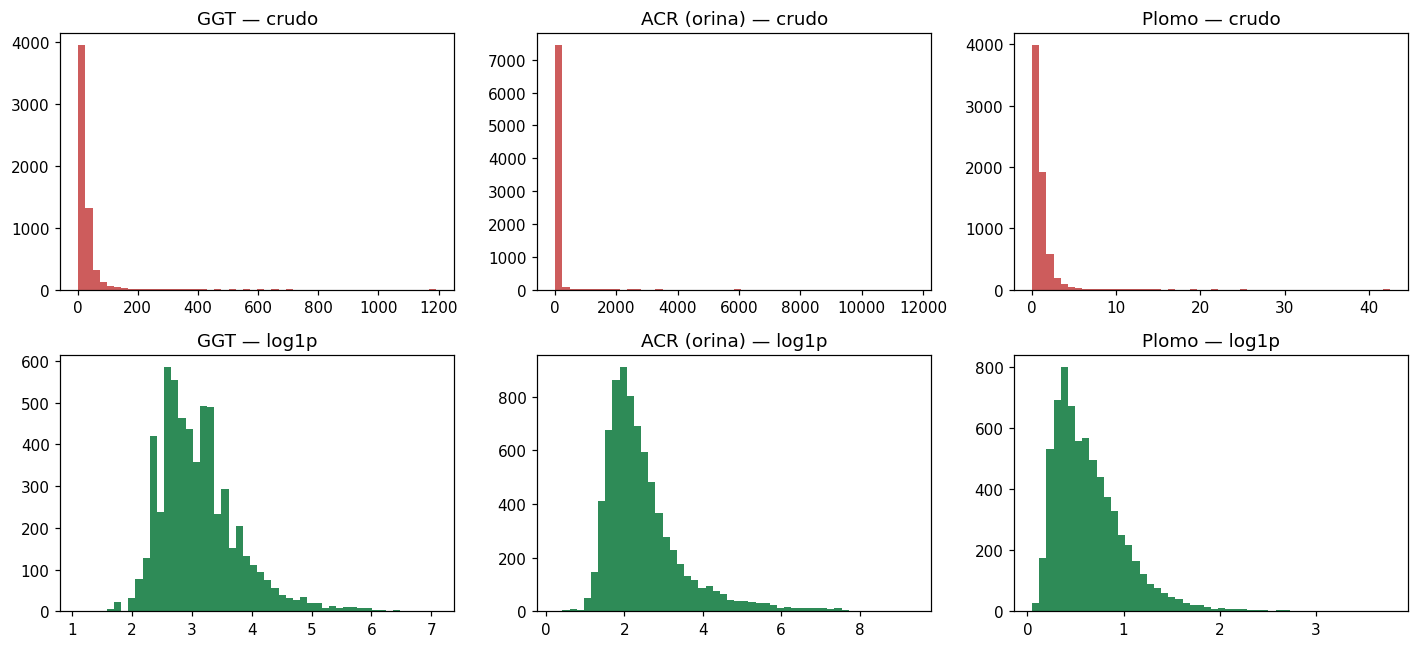

In [11]:
# Grafico 2: antes/despues del log para 3 variables sesgadas
pairs = [("LBXSGTSI", "ggt_log", "GGT"),
         ("URDACT", "acr_log", "ACR (orina)"),
         ("LBXBPB", "plomo_log", "Plomo")]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, (src, new, title) in enumerate(pairs):
    axes[0, j].hist(lab[src].dropna(), bins=50, color="indianred")
    axes[0, j].set_title(f"{title} — crudo")
    axes[1, j].hist(lab[new].dropna(), bins=50, color="seagreen")
    axes[1, j].set_title(f"{title} — log1p")
plt.tight_layout(); plt.show()

## 7. Ingeniería de características intra-grupo

Construimos las derivadas que **no necesitan** datos de otros grupos. Cada derivada
**reemplaza** a sus componentes crudos (Filtro 4 — redundancia).

| Feature | Fórmula | Reemplaza | Nota |
|---|---|---|---|
| `ast_alt_ratio` | AST / ALT (De Ritis) | AST crudo | marcador hepático; conservamos ALT |
| `nlr` | Neutrófilos % / Linfocitos % | neutrófilos % | inflamación / inmunosenescencia. ⚠️ usa linfocitos% (componente del target): se documenta posible solapamiento |
| `no_hdl` | Colesterol total − HDL | colesterol total | mejor predictor lipídico que TC |
| `cotinina_cat` | corte sobre cotinina sérica | — | no fumador / pasivo / fumador activo (≥10 ng/mL) |

**Diferidas al merge con `DEMO`** (necesitan edad/sexo, se calcularán en `04_feature`):
`eGFR` (CKD-EPI 2021, desde creatinina) y el propio **PhenoAge** (target).

In [12]:
# 7.1 Ratio AST/ALT (De Ritis)
if {"LBXSASSI", "LBXSATSI"}.issubset(lab.columns):
    lab["ast_alt_ratio"] = lab["LBXSASSI"] / lab["LBXSATSI"].replace(0, np.nan)

# 7.2 NLR = neutrofilos% / linfocitos%  (linfocitos% es componente del PhenoAge -> caveat)
if {"LBXNEPCT", "LBXLYPCT"}.issubset(lab.columns):
    lab["nlr"] = lab["LBXNEPCT"] / lab["LBXLYPCT"].replace(0, np.nan)

# 7.3 no-HDL = colesterol total - HDL
if {"LBXTC", "LBDHDD"}.issubset(lab.columns):
    lab["no_hdl"] = lab["LBXTC"] - lab["LBDHDD"]

# 7.4 Categoria de tabaquismo desde cotinina serica (ng/mL)
#     <0.05 indetectable ~ no expuesto; 0.05-10 exposicion pasiva; >=10 fumador activo
if "LBXCOT" in lab.columns:
    lab["cotinina_cat"] = pd.cut(
        lab["LBXCOT"], bins=[-np.inf, 0.05, 10, np.inf],
        labels=["no_fumador", "pasivo", "activo"],
    )
    print(lab["cotinina_cat"].value_counts(dropna=False))

cotinina_cat
no_fumador    4041
pasivo        1805
NaN           1265
activo        1255
Name: count, dtype: int64


In [13]:
# Eliminamos los componentes crudos ya reemplazados por derivadas (Filtro 4)
DROP_AFTER_DERIVE = [
    "LBXSASSI",   # AST -> contenido en ast_alt_ratio
    "LBXTC",      # colesterol total -> contenido en no_hdl
    "LBXSGTSI",   # GGT crudo -> ggt_log
    "URDACT",     # ACR crudo -> acr_log
    "LBXBPB",     # plomo crudo -> plomo_log
    "LBXBCD",     # cadmio crudo -> cadmio_log
    "LBXCOT",     # cotinina cruda -> cotinina_log + cotinina_cat
]
lab = lab.drop(columns=[c for c in DROP_AFTER_DERIVE if c in lab.columns])
print("Tras descartar componentes crudos:", lab.shape)

Tras descartar componentes crudos: (8366, 38)


## 8. Renombrado legible y separación target / features

Renombramos las columnas crudas a nombres legibles y marcamos qué columnas son
**reservadas para el target** (PhenoAge) frente a las **features** candidatas.

In [14]:
RENAME = {
    # PhenoAge (reservado_target)
    "LBXSAL": "albumina", "LBXSCR": "creatinina", "LBXSGL": "glucosa_serica",
    "LBXSAPSI": "alp", "LBXHSCRP": "crp", "LBXLYPCT": "linfocitos_pct",
    "LBXMCVSI": "mcv", "LBXRDW": "rdw", "LBXWBCSI": "wbc",
    # features
    "LBXSATSI": "alt", "LBXSUA": "acido_urico", "LBXSBU": "bun",
    "LBXSTB": "bilirrubina_total", "LBXSCA": "calcio", "LBXSTR": "trigliceridos",
    "LBXSGB": "globulina", "LBXSLDSI": "ldh", "LBXSIR": "hierro",
    "LBXNEPCT": "neutrofilos_pct", "LBXMOPCT": "monocitos_pct", "LBXHGB": "hemoglobina",
    "LBXPLTSI": "plaquetas", "LBXMPSI": "mpv", "LBXGH": "hba1c", "LBDHDD": "hdl",
    "LBXVIDMS": "vitamina_d", "LBXTHG": "mercurio", "LBXBSE": "selenio", "LBXBMN": "manganeso",
}
lab = lab.rename(columns=RENAME)

# Listas de control: que es target y que es feature
TARGET_COLS = ["albumina", "creatinina", "glucosa_serica", "alp", "crp",
               "linfocitos_pct", "mcv", "rdw", "wbc"]
TARGET_COLS = [c for c in TARGET_COLS if c in lab.columns]
FEATURE_COLS = [c for c in lab.columns if c not in TARGET_COLS]
print(f"reservado_target ({len(TARGET_COLS)}): {TARGET_COLS}")
print(f"features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

reservado_target (9): ['albumina', 'creatinina', 'glucosa_serica', 'alp', 'crp', 'linfocitos_pct', 'mcv', 'rdw', 'wbc']
features (29): ['alt', 'bun', 'globulina', 'hierro', 'ldh', 'bilirrubina_total', 'calcio', 'trigliceridos', 'acido_urico', 'monocitos_pct', 'neutrofilos_pct', 'hemoglobina', 'plaquetas', 'mpv', 'hba1c', 'hdl', 'vitamina_d', 'mercurio', 'selenio', 'manganeso', 'ggt_log', 'acr_log', 'plomo_log', 'cadmio_log', 'cotinina_log', 'ast_alt_ratio', 'nlr', 'no_hdl', 'cotinina_cat']


## 9. Resumen de calidad: missingness y redundancia

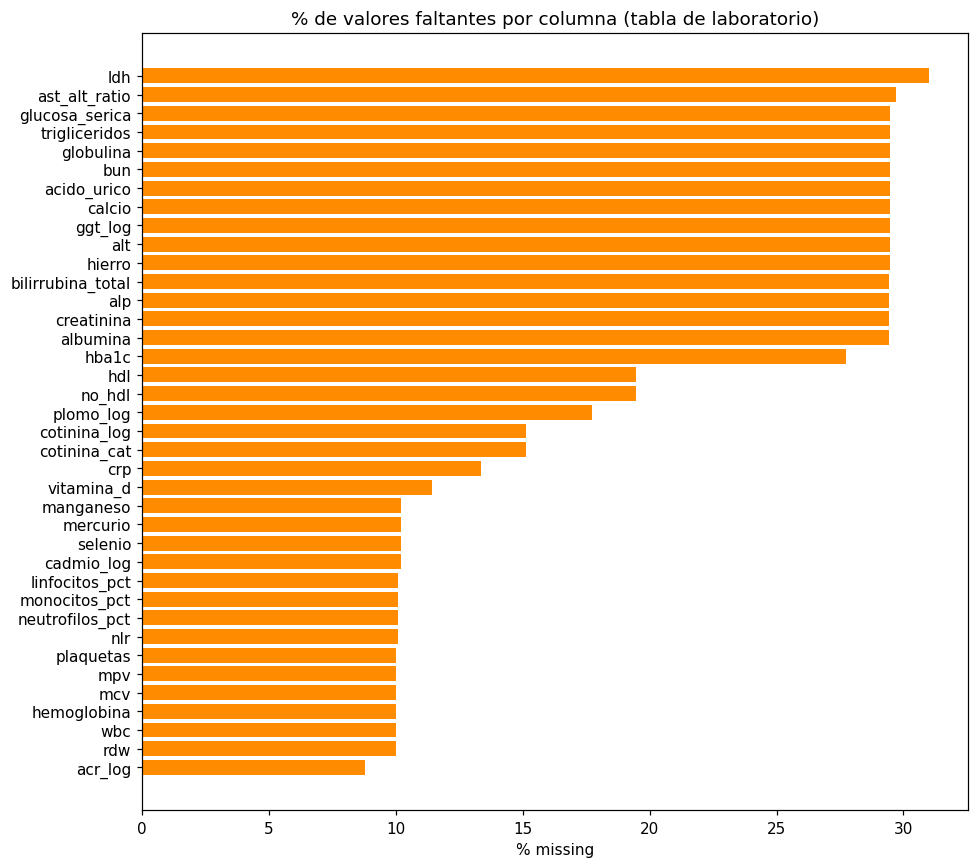

,%_missing
ldh,31.0
ast_alt_ratio,29.7
glucosa_serica,29.5
trigliceridos,29.5
globulina,29.5
bun,29.5
acido_urico,29.5
calcio,29.5
ggt_log,29.5
alt,29.5


In [15]:
# Grafico 3: % de valores faltantes por columna (refleja diseno de submuestras)
miss = (lab.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(miss.index[::-1], miss.values[::-1], color="darkorange")
ax.set_title("% de valores faltantes por columna (tabla de laboratorio)")
ax.set_xlabel("% missing"); plt.tight_layout(); plt.show()
miss.round(1).to_frame("%_missing").head(40)

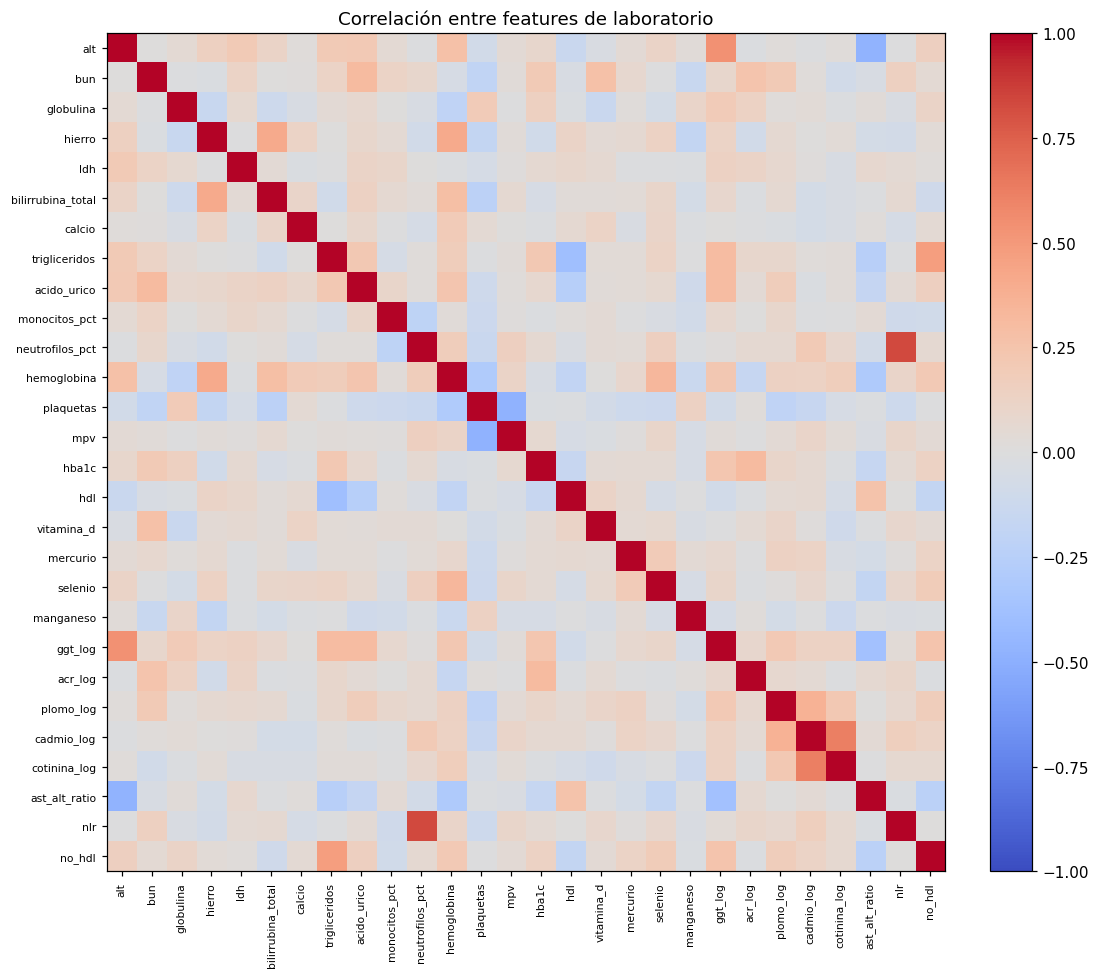

Pares con |r|>0.9: ninguno


In [16]:
# Grafico 4: matriz de correlacion de las features numericas (verificar redundancia)
num = lab[FEATURE_COLS].select_dtypes("number")
corr = num.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlación entre features de laboratorio")
plt.tight_layout(); plt.show()

# Pares con |r|>0.9 (candidatos a redundancia a vigilar en 04_feature)
high = (corr.where(~np.eye(len(corr), dtype=bool)).abs() > 0.9)
pairs = [(corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 2))
         for i in range(len(corr)) for j in range(i+1, len(corr)) if high.iloc[i, j]]
print("Pares con |r|>0.9:", pairs if pairs else "ninguno")

## 10. Exportación a `02_intermediate`

Guardamos la tabla de laboratorio consolidada en formato Parquet (preserva dtypes y es
eficiente). `SEQN` queda como índice/llave para el merge posterior por `SEQN` con los
otros tres grupos y con `DEMO`.

In [17]:
out_path = OUT_DIR / "lab_intermediate.parquet"
lab.to_parquet(out_path)
print("Guardado:", out_path)
print("Shape final:", lab.shape)
print(f"Columnas reservadas para target (PhenoAge): {len(TARGET_COLS)}")
print(f"Features de laboratorio: {len(FEATURE_COLS)}")
lab.head()

Guardado: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate\lab_intermediate.parquet
Shape final: (8366, 38)
Columnas reservadas para target (PhenoAge): 9
Features de laboratorio: 29


,alt,albumina,alp,bun,creatinina,globulina,glucosa_serica,hierro,ldh,bilirrubina_total,calcio,trigliceridos,acido_urico,wbc,linfocitos_pct,monocitos_pct,neutrofilos_pct,hemoglobina,mcv,rdw,plaquetas,mpv,crp,hba1c,hdl,vitamina_d,mercurio,selenio,manganeso,ggt_log,acr_log,plomo_log,cadmio_log,cotinina_log,ast_alt_ratio,nlr,no_hdl,cotinina_cat
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.4,47.8,8.0,42.6,13.1,87.0,12.8,239.0,8.6,0.29,NaN,NaN,74.4,0.47,142.28,9.41,NaN,NaN,NaN,0.067659,NaN,NaN,0.891213,NaN,NaN
93705,16.0,4.4,74.0,11.0,0.92,2.9,85.0,94.0,174.0,0.6,9.2,95.0,5.8,8.6,40.0,7.4,48.8,11.9,67.0,15.6,309.0,7.9,2.72,6.2,60.0,89.9,1.07,185.71,8.57,3.091042,2.662355,1.381282,0.215111,0.027615,1.250000,1.220000,97.0,no_fumador
93706,10.0,4.4,79.0,12.0,0.81,2.7,94.0,163.0,142.0,0.7,9.6,92.0,8.0,6.1,24.6,9.1,61.4,16.3,89.7,12.2,233.0,6.6,0.74,5.2,47.0,53.8,10.64,199.44,14.07,2.833213,4.067145,0.553885,0.190620,0.129272,1.400000,2.495935,101.0,pasivo
93707,13.0,5.2,238.0,17.0,0.64,2.8,115.0,90.0,177.0,0.7,10.1,110.0,5.5,11.2,37.1,6.2,54.7,14.5,83.9,13.6,348.0,8.5,0.32,5.6,68.0,58.2,0.20,179.34,12.60,2.302585,3.039749,0.329304,0.131028,0.441476,1.846154,1.474394,121.0,pasivo


## 11. Conclusiones del grupo Laboratory

- Partimos de **10 datasets** (≈110 columnas crudas con duplicados SI/LC) y llegamos a una
  **tabla única** mucho más compacta.
- Separamos los **9 biomarcadores del PhenoAge** (reservados para construir el target) de las
  **features de laboratorio**, evitando la circularidad.
- Construimos features intra-grupo: `ast_alt_ratio`, `nlr`, `no_hdl`, `cotinina_cat` y las
  versiones log de variables sesgadas (`ggt_log`, `acr_log`, `plomo_log`, `cadmio_log`, `cotinina_log`).
- Quedan **diferidas** al merge con `DEMO`: `eGFR` (necesita edad/sexo) y el **PhenoAge** (target).
- No imputamos ni escalamos aquí: eso ocurre **después del split** train/test para evitar fuga de información.

### Referencias
- Levine, M. E., et al. (2018). *An epigenetic biomarker of aging for lifespan and healthspan.* Aging, 10(4).
- Inker, L. A., et al. (2021). *New creatinine- and cystatin C–based equations to estimate GFR without race.* NEJM.
- CDC/NCHS. *NHANES 2017-2018 Laboratory Data — Documentation & Codebooks.*
